
# MADDPG CTDE baseline 


In [1]:

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from pathlib import Path
import importlib.util
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

%matplotlib inline

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Set QUICK_TEST=True once to validate the full pipeline quickly.
QUICK_TEST = False

# Same main configuration as the uploaded async notebook
M = 8
N = 20
J = 3
P_O = 1e-5

TS = 10_000
EPISODES = 50
HORIZON_T = 256
BATCH_SIZE = 128
REPLAY_SIZE = int(1e5)

ACTOR_LR = 5e-4
CRITIC_LR = 5e-4
GAMMA = 0.99
TAU = 0.005

ACTOR_HIDDEN = [256, 128, 64]
CRITIC_HIDDEN = [512, 256, 128]   # centralized critic sees joint state/action

if QUICK_TEST:
    M = 8
    N = 8
    J = 3
    TS = 400
    EPISODES = 3
    HORIZON_T = 12
    BATCH_SIZE = 8
    REPLAY_SIZE = 2000

print(f"M={M}, N={N}, J={J}, TS={TS}, EPISODES={EPISODES}, HORIZON_T={HORIZON_T}")


Using device: cpu
M=8, N=20, J=3, TS=10000, EPISODES=50, HORIZON_T=256


In [2]:

env_path = Path("./Utils/env_orig_maddpg.py")
if not env_path.exists():
    raise FileNotFoundError("Place env_orig_maddpg.py in the Utils folder.")

spec = importlib.util.spec_from_file_location("env_orig_maddpg", env_path)
env_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(env_module)
env = env_module.env

def generate_matrix(num_subchannels: int, num_devices: int) -> np.ndarray:
    matrix = np.zeros((num_subchannels, num_devices), dtype=np.float32)
    for j in range(num_devices):
        while True:
            row_index = np.random.randint(num_subchannels)
            if np.sum(matrix[row_index]) == 0:
                matrix[row_index, j] = 1.0
                break
    for i in range(num_subchannels):
        if np.sum(matrix[i]) == 0 and np.random.rand() > 0.5:
            col_index = np.random.randint(num_devices)
            matrix[i, col_index] = 1.0
    return matrix

def build_interferers_actions_for_agent(agent_idx: int, joint_actions: list[np.ndarray]) -> np.ndarray:
    return np.stack([joint_actions[k].T for k in range(len(joint_actions)) if k != agent_idx], axis=0)

def get_local_state(environ, alltime_PathGains, alltime_fast_fading_gains, ts: int,
                    agent_idx: int, prev_actions: list[np.ndarray]) -> np.ndarray:
    interferers = build_interferers_actions_for_agent(agent_idx, prev_actions)
    state = environ.get_next_state(
        alltime_PathGains,
        alltime_fast_fading_gains,
        ts=ts,
        b=agent_idx,
        interfers_actions=interferers,
        b_actions=prev_actions[agent_idx]
    )
    return state.astype(np.float32)

def select_unique_max_indices(matrix: np.ndarray) -> list[tuple[int, int]]:
    selected_rows = set()
    result_indices = []
    for j in range(matrix.shape[1]):
        sorted_row_indices = np.argsort(matrix[:, j])[::-1]
        for row in sorted_row_indices:
            if row not in selected_rows:
                selected_rows.add(int(row))
                result_indices.append((int(row), j))
                break
    return result_indices

def quantize_proto_action_urlcc(proto_action: np.ndarray, num_subchannels: int, num_devices: int) -> np.ndarray:
    # Same URLLC-aware discrete action mapping style as the uploaded async notebook.
    uhat = np.asarray(proto_action).reshape(num_subchannels, num_devices)
    u = np.zeros((num_subchannels, num_devices), dtype=np.float32)

    max_indices = select_unique_max_indices(uhat)
    allocated_resources = []
    for row_idx, col_idx in max_indices:
        u[row_idx, col_idx] = 1.0
        allocated_resources.append(row_idx)

    unallocated_resources = [r for r in range(num_subchannels) if r not in allocated_resources]
    v = np.concatenate((np.zeros((1, num_devices)), np.eye(num_devices)), axis=0)

    for r in unallocated_resources:
        ind = np.argmin([np.linalg.norm(uhat[r, :] - v[n, :]) for n in range(v.shape[0])])
        u[r, :] = v[ind, :]

    return u

def return_cdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    sorted_vals = np.sort(values)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    return sorted_vals, cdf


In [3]:

class ReplayBuffer:
    def __init__(self, max_size: int):
        self.buffer = deque(maxlen=max_size)

    def add(self, local_states, joint_state, next_local_states, next_joint_state, joint_action, rewards):
        self.buffer.append((local_states, joint_state, next_local_states, next_joint_state, joint_action, rewards))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        local_states, joint_states, next_local_states, next_joint_states, joint_actions, rewards = zip(*batch)
        return (
            torch.tensor(np.stack(local_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(joint_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(next_local_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(next_joint_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(joint_actions), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(rewards), dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.buffer)

class Actor(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dims: list[int]):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], action_dim)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return torch.sigmoid(self.fc4(x))

class CentralizedCritic(nn.Module):
    def __init__(self, joint_state_dim: int, joint_action_dim: int, hidden_dims: list[int]):
        super().__init__()
        self.fc1 = nn.Linear(joint_state_dim + joint_action_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], 1)

    def forward(self, joint_state: torch.Tensor, joint_action: torch.Tensor) -> torch.Tensor:
        x = torch.cat([joint_state, joint_action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

class MADDPGAgent:
    def __init__(self, state_dim: int, action_dim: int, joint_state_dim: int, joint_action_dim: int):
        self.actor = Actor(state_dim, action_dim, ACTOR_HIDDEN).to(DEVICE)
        self.actor_target = Actor(state_dim, action_dim, ACTOR_HIDDEN).to(DEVICE)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic = CentralizedCritic(joint_state_dim, joint_action_dim, CRITIC_HIDDEN).to(DEVICE)
        self.critic_target = CentralizedCritic(joint_state_dim, joint_action_dim, CRITIC_HIDDEN).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=ACTOR_LR)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=CRITIC_LR)

    def select_action(self, state: np.ndarray, exploration_std: float) -> np.ndarray:
        with torch.no_grad():
            state_tensor = torch.tensor(state.reshape(1, -1), dtype=torch.float32, device=DEVICE)
            proto_action = self.actor(state_tensor).cpu().numpy().flatten()
        noise = np.random.normal(0.0, exploration_std, size=proto_action.shape)
        proto_action = np.clip(proto_action + noise, 0.0, 1.0)
        return proto_action

def soft_update(source: nn.Module, target: nn.Module, tau: float):
    for src_param, tgt_param in zip(source.parameters(), target.parameters()):
        tgt_param.data.copy_(tau * src_param.data + (1.0 - tau) * tgt_param.data)

def train_one_step(agents: list[MADDPGAgent], replay_buffer: ReplayBuffer, state_shape, action_shape):
    if len(replay_buffer) < BATCH_SIZE:
        return None

    local_states, joint_states, next_local_states, next_joint_states, joint_actions, rewards = replay_buffer.sample(BATCH_SIZE)

    batch_size = local_states.shape[0]
    per_agent_state_dim = int(np.prod(state_shape))
    per_agent_action_dim = int(np.prod(action_shape))

    joint_states_flat = joint_states.view(batch_size, -1)
    next_joint_states_flat = next_joint_states.view(batch_size, -1)
    joint_actions_flat = joint_actions.view(batch_size, -1)

    critic_losses = []
    actor_losses = []

    for agent_idx, agent in enumerate(agents):
        with torch.no_grad():
            next_actions_all = []
            for other_idx, other_agent in enumerate(agents):
                next_local_state = next_local_states[:, other_idx].contiguous().view(batch_size, per_agent_state_dim)
                next_action = other_agent.actor_target(next_local_state)
                next_actions_all.append(next_action.view(batch_size, per_agent_action_dim))
            next_joint_actions_flat = torch.cat(next_actions_all, dim=-1)

            target_q = agent.critic_target(next_joint_states_flat, next_joint_actions_flat)
            y = rewards[:, agent_idx:agent_idx + 1] + GAMMA * target_q

        current_q = agent.critic(joint_states_flat, joint_actions_flat)
        critic_loss = F.mse_loss(current_q, y)

        agent.critic_optimizer.zero_grad()
        critic_loss.backward()
        agent.critic_optimizer.step()

        pred_actions_all = []
        for other_idx, other_agent in enumerate(agents):
            local_state = local_states[:, other_idx].contiguous().view(batch_size, per_agent_state_dim)
            if other_idx == agent_idx:
                pred_action = other_agent.actor(local_state)
            else:
                pred_action = other_agent.actor(local_state).detach()
            pred_actions_all.append(pred_action.view(batch_size, per_agent_action_dim))
        pred_joint_actions_flat = torch.cat(pred_actions_all, dim=-1)

        actor_loss = -agent.critic(joint_states_flat, pred_joint_actions_flat).mean()

        agent.actor_optimizer.zero_grad()
        actor_loss.backward()
        agent.actor_optimizer.step()

        soft_update(agent.actor, agent.actor_target, TAU)
        soft_update(agent.critic, agent.critic_target, TAU)

        critic_losses.append(float(critic_loss.detach().cpu()))
        actor_losses.append(float(actor_loss.detach().cpu()))

    return {
        "critic_loss_mean": float(np.mean(critic_losses)),
        "actor_loss_mean": float(np.mean(actor_losses)),
    }


In [4]:

environ = env(Ts=TS, N=N, M=M, J=J)
alltime_fast_fading_gains, ff_gains = environ.fast_fading_channel_coefficients()
TxRxds = environ.compute_TxRX()
alltime_PathGains = environ.large_scale_fading_channel_coefficients(TxRxds)

print("Trace tensors ready.")
print("alltime_fast_fading_gains:", alltime_fast_fading_gains.shape)
print("alltime_PathGains:", alltime_PathGains.shape)


100%|██████████| 9999/9999 [00:01<00:00, 5854.13it/s]


Trace tensors ready.
alltime_fast_fading_gains: (10000, 8, 24, 20)
alltime_PathGains: (10000, 8, 24, 20)


In [5]:

state_shape = (2, N, J)
action_shape = (N, J)

state_dim = int(np.prod(state_shape))
action_dim = int(np.prod(action_shape))
joint_state_dim = M * state_dim
joint_action_dim = M * action_dim

agents = [MADDPGAgent(state_dim, action_dim, joint_state_dim, joint_action_dim) for _ in range(M)]
replay_buffer = ReplayBuffer(REPLAY_SIZE)

prev_actions = [generate_matrix(N, J) for _ in range(M)]
ts_counter = 1

episode_rewards = [[] for _ in range(M)]
episode_mean_bler = [[] for _ in range(M)]
all_step_max_bler = []
loss_history = []

print("Created", len(agents), "MADDPG agents.")


Created 8 MADDPG agents.


In [6]:

for episode in tqdm(range(EPISODES)):
    local_states = [
        get_local_state(environ, alltime_PathGains, alltime_fast_fading_gains, ts_counter, agent_idx, prev_actions)
        for agent_idx in range(M)
    ]

    rewards_this_episode = np.zeros(M, dtype=np.float32)
    bler_this_episode = [[] for _ in range(M)]

    exploration_std = max(1.0 / np.sqrt(episode + 1), 1e-2)

    for t in range(HORIZON_T):
        joint_state = np.stack(local_states, axis=0)

        joint_actions = []
        for agent_idx in range(M):
            proto_action = agents[agent_idx].select_action(local_states[agent_idx], exploration_std)
            discrete_action = quantize_proto_action_urlcc(proto_action, N, J)
            joint_actions.append(discrete_action)

        next_local_states = []
        step_rewards = np.zeros(M, dtype=np.float32)
        step_agent_max_blers = []

        for agent_idx in range(M):
            interferers_actions = build_interferers_actions_for_agent(agent_idx, joint_actions)

            _, p_e_agent, reward_agent = environ.compute_rewards(
                alltime_PathGains,
                alltime_fast_fading_gains,
                ts=min(ts_counter + 1, TS - 1),
                b=agent_idx,
                interfers_actions=interferers_actions,
                b_actions=joint_actions[agent_idx]
            )

            next_state_agent = environ.get_next_state(
                alltime_PathGains,
                alltime_fast_fading_gains,
                ts=min(ts_counter + 1, TS - 1),
                b=agent_idx,
                interfers_actions=interferers_actions,
                b_actions=joint_actions[agent_idx]
            ).astype(np.float32)

            next_local_states.append(next_state_agent)
            step_rewards[agent_idx] = float(np.sum(reward_agent))
            rewards_this_episode[agent_idx] += step_rewards[agent_idx]
            bler_this_episode[agent_idx].extend(np.asarray(p_e_agent).tolist())
            step_agent_max_blers.append(float(np.max(p_e_agent)))

        all_step_max_bler.append(float(np.max(step_agent_max_blers)))

        replay_buffer.add(
            np.stack(local_states, axis=0),
            joint_state,
            np.stack(next_local_states, axis=0),
            np.stack(next_local_states, axis=0),
            np.stack(joint_actions, axis=0),
            step_rewards.astype(np.float32),
        )

        loss_info = train_one_step(agents, replay_buffer, state_shape, action_shape)
        if loss_info is not None:
            loss_history.append(loss_info)

        local_states = next_local_states
        prev_actions = [a.copy() for a in joint_actions]

        ts_counter += 1
        if ts_counter >= TS - 2:
            ts_counter = 1

    for agent_idx in range(M):
        episode_rewards[agent_idx].append(rewards_this_episode[agent_idx] / HORIZON_T)


100%|██████████| 50/50 [1:21:01<00:00, 97.24s/it] 


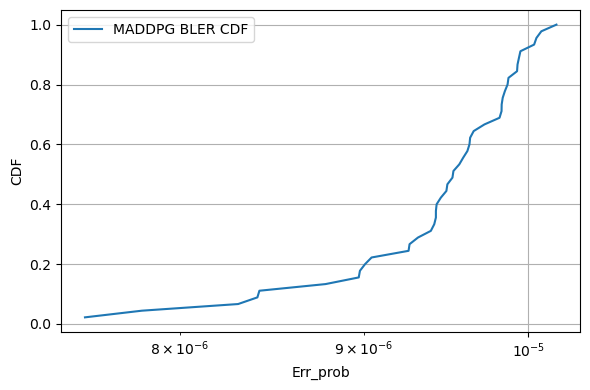

In [7]:
reward_df = pd.DataFrame({
    f"agent_{k+1}": (np.array(episode_rewards[k])) / (N * J)
    for k in range(M)
})

reward_smooth = reward_df.rolling(window=1).mean()


err_prob_df = P_O* (10 ** (-reward_smooth))
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf
err_prob_matrix = err_prob_df.to_numpy()
err_max = np.nanmax(err_prob_matrix, axis=1)
err_max = np.asarray(err_max).reshape(-1)
err_max = err_max[np.isfinite(err_max) & (err_max > 0)]
cutoff = np.percentile(err_max, 10)
err_max_main = err_max[err_max >= cutoff]
a, cdf = return_cdf(err_max_main)
plt.figure(figsize=[6, 4])
plt.semilogx(a, cdf, label='MADDPG BLER CDF')
plt.grid()
plt.xlabel('Err_prob')
plt.ylabel('CDF')
plt.legend()
plt.tight_layout()
plt.show()